In [20]:
# 셀 실행 시간 자동 기록 - 텍스트 정제/학습처럼 무거운 셀이 실제로 몇 초/몇 분 걸리는지
# 매번 직접 시간을 재지 않아도, 이 셀 하나만 먼저 실행해두면 이후 모든 셀 끝에 자동으로 찍힌다.
import time
from IPython import get_ipython

def _cell_time_start(info):
    get_ipython()._cell_start_time = time.time()

def _cell_time_end(result):
    # 이 설정 셀 자신은 pre_run_cell 등록 전에 시작된 상태라 시작 시각이 없다 - 그럴 땐 조용히 넘어간다.
    start = getattr(get_ipython(), '_cell_start_time', None)
    if start is None:
        return
    elapsed = time.time() - start
    if elapsed >= 60:
        print(f'\n[셀 실행 시간: {int(elapsed // 60)}분 {elapsed % 60:.1f}초]')
    else:
        print(f'\n[셀 실행 시간: {elapsed:.2f}초]')

ip = get_ipython()
ip.events.register('pre_run_cell', _cell_time_start)
ip.events.register('post_run_cell', _cell_time_end)

print('셀 실행 시간 기록을 시작합니다 - 이 셀 다음부터 각 셀 끝에 걸린 시간이 표시됩니다.')


셀 실행 시간 기록을 시작합니다 - 이 셀 다음부터 각 셀 끝에 걸린 시간이 표시됩니다.


In [21]:
# 전처리 결과 캐싱(1/2: 불러오기) - 데이터 로드~텍스트 정제까지는 전체 데이터 기준 수 분씩 걸리는데,
# 커널을 새로 켤 때마다 매번 반복하면 아래쪽(모델 구조/epoch 실험)을 한 번 바꿔볼 때마다 이 긴 과정을
# 처음부터 다시 거쳐야 해서 비효율적이다. 그래서 한 번 계산한 결과를 파일로 저장해두고,
# 다음부터는 파일이 있으면 계산을 통째로 건너뛰고 몇 초 만에 불러오기만 한다.
# [주의] 전처리 로직(브랜드 매칭 규칙, 텍스트 정제 방식 등)을 고치면 이 캐시가 예전 로직으로 만든
# 결과라 안 맞을 수 있다 - 그럴 땐 CACHE_PATH 파일을 지우고 다시 실행해서 새로 캐싱해야 한다.
import os
import pickle

CACHE_PATH = 'preprocessed_cache.pkl'

if os.path.exists(CACHE_PATH):
    print(f'캐시 파일 발견 ({CACHE_PATH}) - 아래 전처리 셀들을 건너뛰고 바로 불러옵니다.')
    with open(CACHE_PATH, 'rb') as f:
        _cache = pickle.load(f)
    train_df = _cache['train_df']
    val_df = _cache['val_df']
    test_df = _cache['test_df']
    known_brands = _cache['known_brands']
    brand_pattern = _cache['brand_pattern']
    brand_lower_to_original = _cache['brand_lower_to_original']
    known_cats = _cache['known_cats']
    USE_CACHE = True
    print(f'불러오기 완료 - train {len(train_df):,} / val {len(val_df):,} / test {len(test_df):,}')
else:
    print('캐시 없음 - 아래 셀들에서 데이터 로드부터 텍스트 정제까지 처음부터 계산합니다 (시간이 좀 걸립니다).')
    USE_CACHE = False


캐시 없음 - 아래 셀들에서 데이터 로드부터 텍스트 정제까지 처음부터 계산합니다 (시간이 좀 걸립니다).

[셀 실행 시간: 0.01초]


In [22]:
# 데이터 불러오기 - 릿지 노트북(ridge중점.ipynb)과 같은 원본 데이터/이상치 기준을 쓴다.
# 다만 이 노트북은 "딥러닝답게" 아래 원칙으로 처음부터 다시 짰다.
#   1) 불용어 제거 없음 - TF-IDF 차원을 줄이려던 목적인데 임베딩엔 그 이유가 안 맞아서 뺐다.
#   2) 브랜드/카테고리는 등장 빈도가 너무 낮으면 "희귀" 버킷으로 묶는다 (임베딩이 제대로 못 배우는 문제 예방)
#   3) train/val/test 3분할 - val로 epoch/조기종료를 정하고, test는 맨 마지막에 딱 한 번만 채점
#   4) 시퀀스 길이(maxlen)는 실제 정제된 토큰 길이 분포를 보고 정한다
#   5) OOV(사전에 없는 단어) 비율을 직접 확인한다
# (import/설정은 캐시 여부와 무관하게 항상 필요해서 아래 조건문 밖에 둔다)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer  # 브랜드 후보 중 하나를 고를 때(문맥 유사도)만 사용 - 모델 자체와는 무관
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import copy
from IPython.display import display

RANDOM_STATE = 42  # 릿지 노트북과 동일 - test_df를 같은 행으로 맞추기 위함

# 그래프 한글 깨짐(네모박스) 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

if not USE_CACHE:
    mercari_df = pd.read_csv('../../../data/mercari_train.tsv', sep='\t')

    print(f'전처리 전 : {mercari_df.shape}')
    mercari_df = mercari_df[(mercari_df['price'] > 0) & (mercari_df['price'] <= 2000)]
    print(f'가격 이상치(0원 이하 / 2000달러 초과) 제거 후 : {mercari_df.shape}')

    mercari_df.drop(columns='train_id', inplace=True)
    mercari_df = mercari_df.drop_duplicates()
    mercari_df = mercari_df.reset_index(drop=True)
    print(f'train_id 제거 및 중복 제거 후 : {mercari_df.shape}')

    # 가격 로그 변환 (릿지와 동일 - log1p 스케일에서 학습하고 나중에 expm1로 원래 스케일 복원)
    mercari_df['price'] = np.log1p(mercari_df['price'])
else:
    print('캐시를 사용하므로 원본 tsv 로드는 건너뜁니다.')


device: cuda
전처리 전 : (1482535, 8)
가격 이상치(0원 이하 / 2000달러 초과) 제거 후 : (1481658, 8)
train_id 제거 및 중복 제거 후 : (1481609, 7)

[셀 실행 시간: 7.55초]


In [23]:
# category_name 3단계 분리 (릿지 노트북과 동일 - 구조적 파싱이라 leakage 없음)
if not USE_CACHE:
    def split_category(df, col='category_name'):
        df = df.copy()
        df[col] = df[col].fillna('Unknown/Unknown/Unknown')
        parts = df[col].str.split('/', n=2, expand=True)
        parts.columns = ['cat_main', 'cat_sub', 'cat_sub2']
        parts = parts.fillna('Unknown')
        return pd.concat([df, parts], axis=1)

    mercari_df = split_category(mercari_df)



[셀 실행 시간: 6.37초]


In [24]:
# 결과 확인 - 3단계로 잘 쪼개졌는지 표로 확인 (캐시를 썼으면 mercari_df 자체가 없어서 생략)
if not USE_CACHE:
    display(mercari_df[['category_name', 'cat_main', 'cat_sub', 'cat_sub2']].head())
else:
    print('캐시 사용 중 - 이 확인 단계는 생략합니다.')


,category_name,cat_main,cat_sub,cat_sub2
0,Men/Tops/T-shirts,Men,Tops,T-shirts
1,Electronics/Computers & Tablets/Components & P...,Electronics,Computers & Tablets,Components & Parts
2,Women/Tops & Blouses/Blouse,Women,Tops & Blouses,Blouse
3,Home/Home Décor/Home Décor Accents,Home,Home Décor,Home Décor Accents
4,Women/Jewelry/Necklaces,Women,Jewelry,Necklaces



[셀 실행 시간: 0.01초]


In [25]:
# 3-way 분리: (trainval 80% / test 20%) -> trainval을 다시 (train 70% / val 10%)로 나눈다.
# - test_df : 릿지 노트북과 완전히 같은 행 (test_size=0.2, 같은 random_state) -> RMSLE를 정정당당하게 비교 가능
# - val_df  : 학습 중 epoch/조기종료를 결정할 때만 쓴다. 모델 파라미터도, 사전(vocab)도 학습에 안 씀
# - train_df: 실제로 가중치를 업데이트하고, 모든 사전(브랜드/카테고리/단어 vocab, 스케일러)을 여기서만 만든다
# val을 test처럼 "한 번도 학습에 안 쓴 데이터"로 완전히 격리해야, val 성능을 보고 고른 epoch 수가
# test에서도 믿을 만하다고 말할 수 있다 (안 그러면 val이나 test나 둘 다 "몰래 본 답"이 되어버림).
if not USE_CACHE:
    VAL_SIZE = 0.125  # trainval의 12.5% = 전체의 10%  ->  최종 비율 train 70% / val 10% / test 20%

    trainval_df, test_df = train_test_split(
        mercari_df, test_size=0.2, random_state=RANDOM_STATE
    )
    train_df, val_df = train_test_split(
        trainval_df, test_size=VAL_SIZE, random_state=RANDOM_STATE
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

    total = len(mercari_df)
    print(f'train_df : {train_df.shape}  ({len(train_df)/total:.1%})')
    print(f'val_df   : {val_df.shape}  ({len(val_df)/total:.1%})')
    print(f'test_df  : {test_df.shape}  ({len(test_df)/total:.1%})')
else:
    print(f'train_df : {train_df.shape}')
    print(f'val_df   : {val_df.shape}')
    print(f'test_df  : {test_df.shape}')

train_df : (1037126, 10)  (70.0%)
val_df   : (148161, 10)  (10.0%)
test_df  : (296322, 10)  (20.0%)

[셀 실행 시간: 3.13초]


In [50]:
# brand_name 결측치 채우기 - 릿지 노트북에서 검증까지 마친 로직을 그대로 가져온다 (데이터 품질 문제라 모델과 무관).
# 다만 사전(known_brands)은 train_df에서만 만든다 - val/test는 "적용만" 해서 완전히 안 본 데이터로 남긴다.
# 아래 각 함수가 하는 역할:
#   build_known_brands    : train에서 이미 채워져 있는 brand_name 값들을 모아 "알려진 브랜드 목록"을 만든다.
#   build_brand_pattern   : 그 목록으로 정규식을 만든다. 긴 브랜드명이 먼저 매칭되도록 길이 내림차순 정렬한 뒤
#                            단어 경계(\b)를 넣어 컴파일한다 (왜 정렬이 필요한지는 앞서 얘기했던 그 이유 그대로).
#   find_all_brand_candidates : 텍스트 하나(설명/상품명)를 훑어서, 그 안에 등장하는 (중복 제외) 모든 브랜드
#                            후보와 각 후보 주변 문맥(앞뒤 WINDOW_SIZE 단어)을 찾아 {브랜드: 문맥} 형태로 돌려준다.
#   resolve_ambiguous_brand : 후보가 2개 이상일 때 호출된다. 카테고리 문맥(1순위) -> 상품명(2순위) 순으로
#                            TF-IDF 코사인 유사도를 비교해 가장 그럴듯한 브랜드 하나를 고른다.
#                            둘 다 임계값(SIMILARITY_THRESHOLD)을 못 넘기면 확신 없다고 보고 None을 돌려준다.
#   fill_brand_with_source : brand_col이 비어 있는 행만 골라 위 두 함수로 브랜드를 찾아 채우고, 새로 채운 행에는
#                            source_col에 "어디서 찾았는지"(item_description/name)를 남긴다. 그래도 못 찾으면
#                            그대로 NaN으로 남겨서 나중에 restrict_to_known 단계에서 'Unknown' 처리되게 한다.
#   apply_brand_fill       : 위 fill_brand_with_source를 desc(item_description) -> name 순으로 2단계 적용하는
#                            래퍼. train/val/test 세 데이터에 똑같이 적용하려고 함수로 묶어뒀다.
#   restrict_to_known      : 최종적으로 known_set(=train 기준 목록)에 없는 값은 전부 'Unknown'으로 통일한다
#                            (인코딩 단계에서 unseen 카테고리가 튀어나오는 걸 막기 위한 안전장치).
if not USE_CACHE:
    WINDOW_SIZE = 5
    SIMILARITY_THRESHOLD = 0.15

    def build_known_brands(df, col='brand_name'):
        return sorted(df[col].dropna().unique().tolist())

    def build_brand_pattern(known_brands):
        sorted_brands = sorted([b for b in known_brands if len(b) > 0], key=len, reverse=True)
        escaped = [re.escape(b.lower()) for b in sorted_brands]
        pattern = re.compile(r'\b(' + '|'.join(escaped) + r')\b')
        lower_to_original = {b.lower(): b for b in sorted_brands}
        return pattern, lower_to_original

    def find_all_brand_candidates(text, pattern, lower_to_original, window=WINDOW_SIZE):
        text_lower = str(text).lower()
        candidates = {}
        for match in pattern.finditer(text_lower):
            brand = lower_to_original[match.group(1)]
            if brand in candidates:
                continue
            start, end = match.span()
            before = ' '.join(text_lower[:start].split()[-window:])
            after = ' '.join(text_lower[end:].split()[:window])
            candidates[brand] = f'{before} {match.group(1)} {after}'.strip()
        return candidates

    def resolve_ambiguous_brand(candidates, cat_context, name_context):
        brands = list(candidates.keys())
        windows = list(candidates.values())
        for reference in (cat_context, name_context):
            reference = str(reference).strip()
            if not reference:
                continue
            corpus = windows + [reference]
            try:
                vec = TfidfVectorizer().fit(corpus)
            except ValueError:
                continue
            matrix = vec.transform(corpus)
            sims = cosine_similarity(matrix[:-1], matrix[-1])[:, 0]
            best_idx = int(sims.argmax())
            if sims[best_idx] >= SIMILARITY_THRESHOLD:
                return brands[best_idx]
        return None

    def fill_brand_with_source(df, pattern, lower_to_original, desc_col,
                                brand_col='brand_name', source_col='brand_source'):
        df = df.copy()
        missing_mask = df[brand_col].isna()

        def find_brand(row):
            text = row[desc_col]
            text = '' if pd.isna(text) else text
            candidates = find_all_brand_candidates(text, pattern, lower_to_original)
            if len(candidates) == 0:
                return None
            if len(candidates) == 1:
                return next(iter(candidates))
            cat_context = ' '.join(str(row[c]) for c in ['cat_main', 'cat_sub', 'cat_sub2'])
            name_context = str(row['name'])
            return resolve_ambiguous_brand(candidates, cat_context, name_context)

        found = df.loc[missing_mask].apply(find_brand, axis=1)
        df.loc[missing_mask, brand_col] = found
        newly_filled_mask = missing_mask & df[brand_col].notna()
        df.loc[newly_filled_mask, source_col] = desc_col
        return df

    known_brands = build_known_brands(train_df)
    brand_pattern, brand_lower_to_original = build_brand_pattern(known_brands)
    print(f'train 기준 알려진 브랜드 수 : {len(known_brands)}')

    def apply_brand_fill(df):
        df = df.copy()
        df['brand_source'] = np.where(df['brand_name'].notna(), 'original', 'unmatched')
        df = fill_brand_with_source(df, brand_pattern, brand_lower_to_original, desc_col='item_description')
        df = fill_brand_with_source(df, brand_pattern, brand_lower_to_original, desc_col='name')
        return df

    train_df = apply_brand_fill(train_df)
    val_df = apply_brand_fill(val_df)
    test_df = apply_brand_fill(test_df)
    print('train brand_source :'); print(train_df['brand_source'].value_counts())
    print('val brand_source   :'); print(val_df['brand_source'].value_counts())

    known_brands_set = set(known_brands)

    def restrict_to_known(series, known_set, unknown_value='Unknown'):
        return series.where(series.isin(known_set) & series.notna(), unknown_value)

    train_df['brand_name'] = restrict_to_known(train_df['brand_name'], known_brands_set)
    val_df['brand_name'] = restrict_to_known(val_df['brand_name'], known_brands_set)
    test_df['brand_name'] = restrict_to_known(test_df['brand_name'], known_brands_set)

    known_cats = {}
    for col in ['cat_main', 'cat_sub', 'cat_sub2']:
        known_cats[col] = set(train_df[col].unique())
        val_df[col] = restrict_to_known(val_df[col], known_cats[col])
        test_df[col] = restrict_to_known(test_df[col], known_cats[col])

    print('brand_name == Unknown (train):', (train_df['brand_name'] == 'Unknown').sum())
    print('brand_name == Unknown (val)  :', (val_df['brand_name'] == 'Unknown').sum())
    print('brand_name == Unknown (test) :', (test_df['brand_name'] == 'Unknown').sum())
else:
    print(f'train 기준 알려진 브랜드 수 : {len(known_brands)} (캐시에서 불러옴)')
    print('brand_name == Unknown (train):', (train_df['brand_name'] == 'Unknown').sum())
    print('brand_name == Unknown (val)  :', (val_df['brand_name'] == 'Unknown').sum())
    print('brand_name == Unknown (test) :', (test_df['brand_name'] == 'Unknown').sum())

train 기준 알려진 브랜드 수 : 4398
train brand_source :
brand_source
original    1037126
Name: count, dtype: int64
val brand_source   :
brand_source
original    148161
Name: count, dtype: int64
brand_name == Unknown (train): 167472
brand_name == Unknown (val)  : 24243
brand_name == Unknown (test) : 47993

[셀 실행 시간: 3.99초]


In [27]:
# 추가 feature: 설명 유무 플래그 / 텍스트 길이 (릿지 노트북과 동일 - 원문 상태에서 계산)
if not USE_CACHE:
    for df in (train_df, val_df, test_df):
        df['has_description'] = (
            df['item_description'].fillna('No description yet') != 'No description yet'
        ).astype(int)
        df['name_len'] = df['name'].fillna('').apply(lambda x: len(str(x).split()))
        df['desc_len'] = df['item_description'].fillna('No description yet').apply(lambda x: len(str(x).split()))



[셀 실행 시간: 4.96초]


In [28]:
# 결과 확인 - count(80만+)처럼 자리수가 큰 값과 mean/std 같은 작은 소수가 한 표에 섞이면
# pandas가 보기 편하라고 과학적 표기(예: 1.037126e+06)로 바꿔버리는 경우가 있어서,
# 이 표를 보여줄 때만 표시 형식을 "천단위 콤마 + 소수 2자리"로 고정해 전부 실수 그대로 보이게 한다.
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(train_df[['has_description', 'name_len', 'desc_len']].describe())


,has_description,name_len,desc_len
count,"1,037,126.00","1,037,126.00","1,037,126.00"
mean,0.94,4.40,25.68
std,0.23,1.65,30.38
min,0.00,1.00,1.00
25%,1.00,3.00,7.00
50%,1.00,4.00,15.00
75%,1.00,6.00,31.00
max,1.00,17.00,245.00



[셀 실행 시간: 0.08초]


In [29]:
# 텍스트 정제 - 릿지 노트북과 달리 "불용어 제거는 하지 않는다".
# 불용어 제거는 TF-IDF 차원을 줄이려는 목적이 컸는데, 임베딩은 단어 하나당 차원이 고정이라
# 그 이유가 그대로 적용되지 않는다. 대신 소문자화 / 영문자·숫자만 남기기 / 토큰화까지만 하고,
# 어떤 단어를 버릴지는 모델이 임베딩 가중치로 알아서 학습하게 둔다.
if not USE_CACHE:
    import nltk
    from nltk.tokenize import word_tokenize
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)

    def text_cleaning(text):
        text = text.lower()
        text = re.sub(r'[^a-z0-9\s]', ' ', text)   # 숫자는 유지 (4gb, 32gb 등 가격에 영향 줄 수 있는 정보)
        text = re.sub(r'\s+', ' ', text)
        return text.strip()

    def preprocess_text(text):
        return word_tokenize(text_cleaning(text))

    def clean_text_columns(df):
        df = df.copy()
        df['item_description'] = df['item_description'].fillna('No description yet').astype(str)
        df['name'] = df['name'].fillna('').astype(str)
        df['name_tokens'] = df['name'].apply(preprocess_text)
        df['desc_tokens'] = df['item_description'].apply(preprocess_text)
        return df

    # 데이터 규모가 커서 시간이 다소 걸릴 수 있음 (수 분 단위) - 여기까지가 캐싱되는 구간이다.
    train_df = clean_text_columns(train_df)
    val_df = clean_text_columns(val_df)
    test_df = clean_text_columns(test_df)



[셀 실행 시간: 4분 33.6초]


In [30]:
# 전처리 결과 캐싱(2/2: 저장하기) - 방금 새로 계산했을 때만(캐시가 없었을 때만) 다음번을 위해 파일로 저장해둔다.
if not USE_CACHE:
    with open(CACHE_PATH, 'wb') as f:
        pickle.dump({
            'train_df': train_df, 'val_df': val_df, 'test_df': test_df,
            'known_brands': known_brands, 'brand_pattern': brand_pattern,
            'brand_lower_to_original': brand_lower_to_original, 'known_cats': known_cats,
        }, f)
    print(f'전처리 결과를 {CACHE_PATH}에 저장했습니다 - 다음 실행부터는 이 파일에서 바로 불러옵니다.')
    print('(전처리 로직을 고쳤다면 이 파일을 지우고 다시 실행해야 새 로직이 반영됩니다)')
else:
    print('캐시에서 불러온 데이터라 다시 저장하지 않습니다.')


전처리 결과를 preprocessed_cache.pkl에 저장했습니다 - 다음 실행부터는 이 파일에서 바로 불러옵니다.
(전처리 로직을 고쳤다면 이 파일을 지우고 다시 실행해야 새 로직이 반영됩니다)

[셀 실행 시간: 22.49초]


In [31]:
# 결과 확인 - 정제된 토큰이 잘 만들어졌는지 표로 확인
train_df[['name', 'name_tokens', 'desc_tokens']].head()


,name,name_tokens,desc_tokens
0,BEBE SPORT SUIT,"[bebe, sport, suit]","[bebe, sport, jacket, and, yoga, pants, xs]"
1,Indian Henna/mehendhi Tattoo Paste Cones,"[indian, henna, mehendhi, tattoo, paste, cones]","[each, henna, mehendhi, paste, cone, is, 25gms..."
2,The balm nude tude new,"[the, balm, nude, tude, new]","[brand, new]"
3,"Jeffree star ""Scorpio""","[jeffree, star, scorpio]","[never, used]"
4,PINK Crop Top,"[pink, crop, top]","[soft, excellent, condition, comes, a, slight,..."



[셀 실행 시간: 0.01초]


In [32]:
# 시퀀스 길이(maxlen) 결정 - "정제 전 단어 수"가 아니라 실제로 임베딩에 들어갈 "정제 후 토큰 수" 분포를 직접 보고 정한다.
# (불용어를 안 지웠으니 정제 전/후 길이가 거의 비슷하긴 하지만, 문장부호가 분리되면서 토큰 수가 늘어나는
#  경우도 있어 실제 분포를 보는 게 정확하다)
name_token_len = train_df['name_tokens'].apply(len)
desc_token_len = train_df['desc_tokens'].apply(len)



[셀 실행 시간: 0.66초]


In [33]:
# 결과 확인 - name/description 토큰 길이 분포를 한 표로 나란히 비교 (역시 과학적 표기 방지 처리)
token_len_summary = pd.DataFrame({
    'name': name_token_len.describe(percentiles=[.5, .75, .9, .95, .99]),
    'description': desc_token_len.describe(percentiles=[.5, .75, .9, .95, .99]),
})
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(token_len_summary)


,name,description
count,"1,037,126.00","1,037,126.00"
mean,4.51,25.94
std,1.71,30.50
min,0.00,0.00
50%,4.00,15.00
75%,6.00,31.00
90%,7.00,62.00
95%,7.00,91.00
99%,8.00,156.00
max,17.00,269.00



[셀 실행 시간: 0.06초]


In [34]:
# 위 표의 95백분위수를 기준으로 maxlen을 정한다 - 대부분은 안 잘리고, 아주 긴 꼬리만 잘라낸다.
NAME_MAXLEN = int(np.ceil(name_token_len.quantile(0.95)))
DESC_MAXLEN = int(np.ceil(desc_token_len.quantile(0.95)))
print(f'NAME_MAXLEN = {NAME_MAXLEN} (95백분위수 기준)')
print(f'DESC_MAXLEN = {DESC_MAXLEN} (95백분위수 기준)')


NAME_MAXLEN = 7 (95백분위수 기준)
DESC_MAXLEN = 91 (95백분위수 기준)

[셀 실행 시간: 0.02초]


In [35]:
# 어휘 사전(vocab) 구축 - train_df 토큰만 사용(leakage 방지), 등장 빈도 상위 N개만 사용
# (릿지의 TfidfVectorizer(max_features=...)와 같은 역할 - 너무 희귀한 단어는 버려서 임베딩 테이블 크기를 제한한다)
# 인덱스 0 = 패딩(PAD), 1 = 사전에 없는 단어(UNK)
from collections import Counter

NAME_VOCAB_SIZE = 30000   # 릿지 name TfidfVectorizer의 max_features와 맞춤
DESC_VOCAB_SIZE = 50000   # 릿지 description TfidfVectorizer의 max_features와 맞춤

def build_vocab(token_series, vocab_size):
    counter = Counter()
    for tokens in token_series:
        counter.update(tokens)
    most_common = [w for w, _ in counter.most_common(vocab_size)]
    return {w: i + 2 for i, w in enumerate(most_common)}  # 0=PAD, 1=UNK

name_vocab = build_vocab(train_df['name_tokens'], NAME_VOCAB_SIZE)
desc_vocab = build_vocab(train_df['desc_tokens'], DESC_VOCAB_SIZE)
print(f'name 어휘 수 : {len(name_vocab)} (+PAD/UNK)')
print(f'description 어휘 수 : {len(desc_vocab)} (+PAD/UNK)')

def tokens_to_padded_ids(token_series, vocab, maxlen):
    # 토큰 리스트 -> 정수 인덱스로 바꾼 뒤 고정 길이로 패딩/절단. UNK=1, PAD=0(뒷자리 채움).
    ids = np.zeros((len(token_series), maxlen), dtype=np.int64)
    for i, tokens in enumerate(token_series):
        idx = [vocab.get(t, 1) for t in tokens[:maxlen]]
        ids[i, :len(idx)] = idx
    return ids

name_train_ids = tokens_to_padded_ids(train_df['name_tokens'], name_vocab, NAME_MAXLEN)
name_val_ids = tokens_to_padded_ids(val_df['name_tokens'], name_vocab, NAME_MAXLEN)
name_test_ids = tokens_to_padded_ids(test_df['name_tokens'], name_vocab, NAME_MAXLEN)
desc_train_ids = tokens_to_padded_ids(train_df['desc_tokens'], desc_vocab, DESC_MAXLEN)
desc_val_ids = tokens_to_padded_ids(val_df['desc_tokens'], desc_vocab, DESC_MAXLEN)
desc_test_ids = tokens_to_padded_ids(test_df['desc_tokens'], desc_vocab, DESC_MAXLEN)

print('name 시퀀스 shape       :', name_train_ids.shape, name_val_ids.shape, name_test_ids.shape)
print('description 시퀀스 shape:', desc_train_ids.shape, desc_val_ids.shape, desc_test_ids.shape)

name 어휘 수 : 30000 (+PAD/UNK)
description 어휘 수 : 50000 (+PAD/UNK)
name 시퀀스 shape       : (1037126, 7) (148161, 7) (296322, 7)
description 시퀀스 shape: (1037126, 91) (148161, 91) (296322, 91)

[셀 실행 시간: 16.43초]


In [36]:
# OOV(사전에 없는 단어) 비율 확인 - TF-IDF는 사전에 없는 단어를 그냥 무시(기여도 0)하지만,
# 임베딩은 UNK 토큰 하나로 몰아서 최소한의 신호("이 자리에 모르는 단어가 있다")는 남긴다.
# 그 차이가 실제로 얼마나 되는지, val/test에서 사전 밖 단어가 몇 %인지 직접 세어본다.
def oov_rate(token_series, vocab):
    total, oov = 0, 0
    for tokens in token_series:
        total += len(tokens)
        oov += sum(1 for t in tokens if t not in vocab)
    return oov / total if total else 0.0

for split_name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    name_oov = oov_rate(df['name_tokens'], name_vocab)
    desc_oov = oov_rate(df['desc_tokens'], desc_vocab)
    print(f'[{split_name:5s}] name OOV 비율 : {name_oov:.2%}   description OOV 비율 : {desc_oov:.2%}')

[train] name OOV 비율 : 1.40%   description OOV 비율 : 0.38%
[val  ] name OOV 비율 : 1.71%   description OOV 비율 : 0.48%
[test ] name OOV 비율 : 1.72%   description OOV 비율 : 0.47%

[셀 실행 시간: 5.91초]


In [37]:
# 브랜드/카테고리 라벨 인코딩 - 원-핫(수천 차원)이 아니라 정수 id 하나로만 바꾼다 (임베딩 레이어 조회용 인덱스).
# [개선] 등장 횟수가 MIN_CATEGORY_FREQ 미만인 값은 "희귀" 버킷(=0)으로 묶는다.
# 원-핫+릿지는 1번만 나온 브랜드도 계수 하나만 학습하면 그만이지만, 임베딩은 그 브랜드의 벡터 전체를
# 몇 번 안 되는 그래디언트 업데이트만으로 학습해야 해서 훨씬 불안정하다 - 이걸 막기 위한 표준적인 처리다.
# (val/test에만 나오고 train에는 아예 없는 값도 자연스럽게 같은 0번 버킷으로 들어간다)
MIN_CATEGORY_FREQ = 10

def build_label_vocab(series, min_freq=MIN_CATEGORY_FREQ):
    counts = series.value_counts()
    frequent = sorted(counts[counts >= min_freq].index.tolist())
    return {c: i + 1 for i, c in enumerate(frequent)}  # 0 = 희귀/미확인 통합 버킷

def encode_labels(series, vocab):
    return series.map(vocab).fillna(0).astype(np.int64).values

brand_vocab = build_label_vocab(train_df['brand_name'])
cat_main_vocab = build_label_vocab(train_df['cat_main'])
cat_sub_vocab = build_label_vocab(train_df['cat_sub'])
cat_sub2_vocab = build_label_vocab(train_df['cat_sub2'])

print(f'브랜드 : 전체 {train_df["brand_name"].nunique()}종 -> 빈도 {MIN_CATEGORY_FREQ}회 이상만 개별 임베딩 {len(brand_vocab)}종 (나머지는 희귀 버킷)')
print(f'cat_main  : {train_df["cat_main"].nunique()}종 -> {len(cat_main_vocab)}종')
print(f'cat_sub   : {train_df["cat_sub"].nunique()}종 -> {len(cat_sub_vocab)}종')
print(f'cat_sub2  : {train_df["cat_sub2"].nunique()}종 -> {len(cat_sub2_vocab)}종')

brand_train_ids = encode_labels(train_df['brand_name'], brand_vocab)
brand_val_ids = encode_labels(val_df['brand_name'], brand_vocab)
brand_test_ids = encode_labels(test_df['brand_name'], brand_vocab)
cat_main_train_ids = encode_labels(train_df['cat_main'], cat_main_vocab)
cat_main_val_ids = encode_labels(val_df['cat_main'], cat_main_vocab)
cat_main_test_ids = encode_labels(test_df['cat_main'], cat_main_vocab)
cat_sub_train_ids = encode_labels(train_df['cat_sub'], cat_sub_vocab)
cat_sub_val_ids = encode_labels(val_df['cat_sub'], cat_sub_vocab)
cat_sub_test_ids = encode_labels(test_df['cat_sub'], cat_sub_vocab)
cat_sub2_train_ids = encode_labels(train_df['cat_sub2'], cat_sub2_vocab)
cat_sub2_val_ids = encode_labels(val_df['cat_sub2'], cat_sub2_vocab)
cat_sub2_test_ids = encode_labels(test_df['cat_sub2'], cat_sub2_vocab)

rare_ratio_train = (brand_train_ids == 0).mean()
print(f'\ntrain에서 브랜드가 "희귀" 버킷(0번)으로 들어간 비율 : {rare_ratio_train:.1%}')

브랜드 : 전체 4398종 -> 빈도 10회 이상만 개별 임베딩 2187종 (나머지는 희귀 버킷)
cat_main  : 11종 -> 11종
cat_sub   : 114종 -> 114종
cat_sub2  : 861종 -> 670종

train에서 브랜드가 "희귀" 버킷(0번)으로 들어간 비율 : 0.7%

[셀 실행 시간: 3.25초]


In [38]:
# 수치형 피처 스케일링 - train_df로만 fit, val/test는 transform만 (릿지 노트북과 동일 원칙)
numeric_cols = ['item_condition_id', 'has_description', 'name_len', 'desc_len']
scaler = StandardScaler()
X_num_train = scaler.fit_transform(train_df[numeric_cols]).astype(np.float32)
X_num_val = scaler.transform(val_df[numeric_cols]).astype(np.float32)
X_num_test = scaler.transform(test_df[numeric_cols]).astype(np.float32)
print('수치형 스케일링 shape :', X_num_train.shape, X_num_val.shape, X_num_test.shape)

수치형 스케일링 shape : (1037126, 4) (148161, 4) (296322, 4)

[셀 실행 시간: 0.13초]


In [39]:
# PyTorch Dataset/DataLoader 구성 - train/val/test 세 개를 모두 같은 방식으로 텐서로 묶는다.
class MercariDataset(Dataset):
    def __init__(self, brand_ids, cat_main_ids, cat_sub_ids, cat_sub2_ids,
                 name_ids, desc_ids, num_feats, shipping, y):
        self.brand_ids = torch.as_tensor(brand_ids, dtype=torch.long)
        self.cat_main_ids = torch.as_tensor(cat_main_ids, dtype=torch.long)
        self.cat_sub_ids = torch.as_tensor(cat_sub_ids, dtype=torch.long)
        self.cat_sub2_ids = torch.as_tensor(cat_sub2_ids, dtype=torch.long)
        self.name_ids = torch.as_tensor(name_ids, dtype=torch.long)
        self.desc_ids = torch.as_tensor(desc_ids, dtype=torch.long)
        self.num_feats = torch.as_tensor(num_feats, dtype=torch.float32)
        self.shipping = torch.as_tensor(shipping.values.astype(np.float32), dtype=torch.float32)
        self.y = torch.as_tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.brand_ids)

    def __getitem__(self, idx):
        x = (
            self.brand_ids[idx], self.cat_main_ids[idx], self.cat_sub_ids[idx], self.cat_sub2_ids[idx],
            self.name_ids[idx], self.desc_ids[idx], self.num_feats[idx], self.shipping[idx],
        )
        return x, self.y[idx]

def make_dataset(df, brand_ids, cat_main_ids, cat_sub_ids, cat_sub2_ids, name_ids, desc_ids, num_feats):
    return MercariDataset(brand_ids, cat_main_ids, cat_sub_ids, cat_sub2_ids,
                           name_ids, desc_ids, num_feats, df['shipping'], df['price'].values)

train_dataset = make_dataset(train_df, brand_train_ids, cat_main_train_ids, cat_sub_train_ids, cat_sub2_train_ids,
                              name_train_ids, desc_train_ids, X_num_train)
val_dataset = make_dataset(val_df, brand_val_ids, cat_main_val_ids, cat_sub_val_ids, cat_sub2_val_ids,
                            name_val_ids, desc_val_ids, X_num_val)
test_dataset = make_dataset(test_df, brand_test_ids, cat_main_test_ids, cat_sub_test_ids, cat_sub2_test_ids,
                             name_test_ids, desc_test_ids, X_num_test)

BATCH_SIZE = 1024
# num_workers=0: 윈도우에서 멀티프로세스 DataLoader가 노트북 안에서 말썽을 일으키는 경우가 많아 안전하게 0으로 고정
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('train batch 수 :', len(train_loader), ' val batch 수 :', len(val_loader), ' test batch 수 :', len(test_loader))

train batch 수 : 1013  val batch 수 : 145  test batch 수 : 290

[셀 실행 시간: 0.10초]


In [40]:
# 모델 정의 - 릿지의 "원-핫 + TF-IDF + 선형결합"을 "임베딩 + MLP(비선형)"로 바꾼 버전.
#   - 브랜드/카테고리: 원-핫 대신 저차원 임베딩 벡터 (희귀 값은 0번 버킷 하나를 공유)
#   - name/description: TF-IDF 대신, 문장 안 단어 임베딩을 평균낸 벡터
#     (nn.EmbeddingBag(mode='mean')을 쓰면 패딩(PAD=0)은 자동으로 평균 계산에서 빠진다 -
#      RNN처럼 순서를 보진 않지만 그만큼 훨씬 가볍고 빠르다. "딥 bag-of-words" 접근이다.)
#   - 마지막에 이 벡터들을 다 이어붙여서 Dense층 여러 개(=MLP)를 통과시켜 가격(log1p)을 예측한다.
class MercariMLP(nn.Module):
    def __init__(self, n_brand, n_cat_main, n_cat_sub, n_cat_sub2,
                 name_vocab_size, desc_vocab_size, n_numeric=4,
                 brand_dim=16, cat_dim=8, word_dim=32, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.brand_emb = nn.Embedding(n_brand + 1, brand_dim, padding_idx=0)
        self.cat_main_emb = nn.Embedding(n_cat_main + 1, cat_dim, padding_idx=0)
        self.cat_sub_emb = nn.Embedding(n_cat_sub + 1, cat_dim, padding_idx=0)
        self.cat_sub2_emb = nn.Embedding(n_cat_sub2 + 1, cat_dim, padding_idx=0)
        self.name_emb = nn.EmbeddingBag(name_vocab_size + 2, word_dim, mode='mean', padding_idx=0)
        self.desc_emb = nn.EmbeddingBag(desc_vocab_size + 2, word_dim, mode='mean', padding_idx=0)

        concat_dim = brand_dim + cat_dim * 3 + word_dim * 2 + n_numeric + 1  # +1 = shipping
        self.mlp = nn.Sequential(
            nn.Linear(concat_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, brand_ids, cat_main_ids, cat_sub_ids, cat_sub2_ids, name_ids, desc_ids, num_feats, shipping):
        parts = [
            self.brand_emb(brand_ids),
            self.cat_main_emb(cat_main_ids),
            self.cat_sub_emb(cat_sub_ids),
            self.cat_sub2_emb(cat_sub2_ids),
            self.name_emb(name_ids),
            self.desc_emb(desc_ids),
            num_feats,
            shipping.unsqueeze(1),
        ]
        x = torch.cat(parts, dim=1)
        return self.mlp(x).squeeze(1)

model = MercariMLP(
    n_brand=len(brand_vocab), n_cat_main=len(cat_main_vocab),
    n_cat_sub=len(cat_sub_vocab), n_cat_sub2=len(cat_sub2_vocab),
    name_vocab_size=len(name_vocab), desc_vocab_size=len(desc_vocab),
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'전체 파라미터 수 : {n_params:,}')

MercariMLP(
  (brand_emb): Embedding(2188, 16, padding_idx=0)
  (cat_main_emb): Embedding(12, 8, padding_idx=0)
  (cat_sub_emb): Embedding(115, 8, padding_idx=0)
  (cat_sub2_emb): Embedding(671, 8, padding_idx=0)
  (name_emb): EmbeddingBag(30002, 32, mode='mean', padding_idx=0)
  (desc_emb): EmbeddingBag(50002, 32, mode='mean', padding_idx=0)
  (mlp): Sequential(
    (0): Linear(in_features=109, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)
전체 파라미터 수 : 2,662,705

[셀 실행 시간: 0.07초]


In [ ]:
# 학습 - loss로 MSE를 쓰는데, y가 이미 log1p(price)라서 이 MSE의 제곱근이 곧 RMSLE와 같다 (릿지 때와 동일한 원리).
# [개선] val RMSLE 기준 조기종료(early stopping): PATIENCE epoch 동안 val이 안 좋아지면 멈추고,
# 가장 좋았던 시점의 가중치로 되돌린다. test는 여기서 전혀 등장하지 않는다 - 맨 마지막에 딱 한 번만 쓴다.
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, n_samples = 0.0, 0
    criterion = nn.MSELoss()

    with torch.set_grad_enabled(is_train):
        for (brand_ids, cat_main_ids, cat_sub_ids, cat_sub2_ids, name_ids, desc_ids, num_feats, shipping), y in loader:
            brand_ids, cat_main_ids = brand_ids.to(device), cat_main_ids.to(device)
            cat_sub_ids, cat_sub2_ids = cat_sub_ids.to(device), cat_sub2_ids.to(device)
            name_ids, desc_ids = name_ids.to(device), desc_ids.to(device)
            num_feats, shipping, y = num_feats.to(device), shipping.to(device), y.to(device)

            pred = model(brand_ids, cat_main_ids, cat_sub_ids, cat_sub2_ids, name_ids, desc_ids, num_feats, shipping)
            loss = criterion(pred, y)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * len(y)
            n_samples += len(y)

    return total_loss / n_samples  # 이미 log1p 스케일에서의 MSE

N_EPOCHS = 30
PATIENCE = 3
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

best_val_rmsle = float('inf')
best_state = None
epochs_without_improve = 0
history = []

for epoch in range(1, N_EPOCHS + 1):
    train_mse = run_epoch(model, train_loader, optimizer)
    val_mse = run_epoch(model, val_loader, optimizer=None)
    train_rmsle, val_rmsle = np.sqrt(train_mse), np.sqrt(val_mse)
    history.append({'epoch': epoch, 'train_rmsle': train_rmsle, 'val_rmsle': val_rmsle})
    print(f'epoch {epoch:2d}/{N_EPOCHS}  train RMSLE={train_rmsle:.5f}  val RMSLE={val_rmsle:.5f}', end='')

    if val_rmsle < best_val_rmsle:
        best_val_rmsle = val_rmsle
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improve = 0
        print('  <- best')
    else:
        epochs_without_improve += 1
        print(f'  (연속 {epochs_without_improve}회 개선 없음)')
        if epochs_without_improve >= PATIENCE:
            print(f'\nval RMSLE가 {PATIENCE}epoch 연속 개선되지 않아 조기 종료합니다.')
            break

model.load_state_dict(best_state)  # 가장 좋았던 시점으로 복원
history_df = pd.DataFrame(history)
print(f'\n최적 val RMSLE : {best_val_rmsle:.5f} (epoch {history_df.loc[history_df["val_rmsle"].idxmin(), "epoch"]:.0f})')

epoch  1/30  train RMSLE=0.42623  val RMSLE=0.44994  <- best
epoch  2/30  train RMSLE=0.42378  val RMSLE=0.45217  (연속 1회 개선 없음)


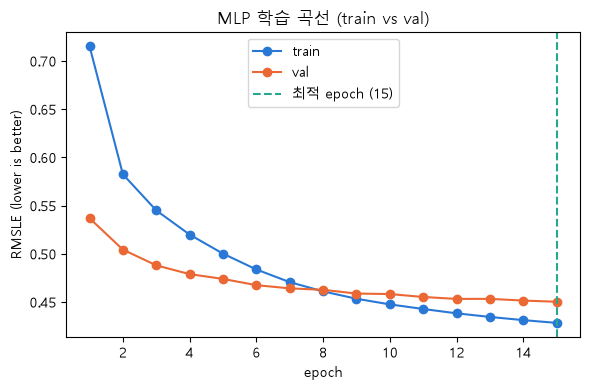


[셀 실행 시간: 0.19초]


In [42]:
# 학습 곡선 - train/val RMSLE가 에폭이 갈수록 어떻게 움직이는지 확인
plt.figure(figsize=(6, 4))
plt.plot(history_df['epoch'], history_df['train_rmsle'], marker='o', color='#2a78d6', label='train')
plt.plot(history_df['epoch'], history_df['val_rmsle'], marker='o', color='#eb6834', label='val')
best_epoch = history_df.loc[history_df['val_rmsle'].idxmin(), 'epoch']
plt.axvline(best_epoch, color='#26a88f', linestyle='--', label=f'최적 epoch ({best_epoch:.0f})')
plt.xlabel('epoch')
plt.ylabel('RMSLE (lower is better)')
plt.title('MLP 학습 곡선 (train vs val)')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# 최종 평가 - test_df는 여기서 "딱 한 번" 등장한다. best_state(=val 기준 최적 시점)로 복원된 모델로 채점.
def predict_log(model, loader):
    model.eval()
    preds = []
    with torch.no_grad():
        for (brand_ids, cat_main_ids, cat_sub_ids, cat_sub2_ids, name_ids, desc_ids, num_feats, shipping), y in loader:
            brand_ids, cat_main_ids = brand_ids.to(device), cat_main_ids.to(device)
            cat_sub_ids, cat_sub2_ids = cat_sub_ids.to(device), cat_sub2_ids.to(device)
            name_ids, desc_ids = name_ids.to(device), desc_ids.to(device)
            num_feats, shipping = num_feats.to(device), shipping.to(device)
            pred = model(brand_ids, cat_main_ids, cat_sub_ids, cat_sub2_ids, name_ids, desc_ids, num_feats, shipping)
            preds.append(pred.cpu().numpy())
    return np.concatenate(preds)

def rmsle_on_log_scale(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

pred_log = predict_log(model, test_loader)
test_rmsle = rmsle_on_log_scale(test_df['price'].values, pred_log)

print(f'[MLP] 최종 test RMSLE : {test_rmsle:.5f}   (val 기준 최적 epoch {best_epoch:.0f}의 가중치로 평가)')
print(f'[참고] 릿지 최종 RMSLE(alpha=3.1623, test) : 0.45223')

[MLP] 최종 test RMSLE : 0.45137   (val 기준 최적 epoch 15의 가중치로 평가)
[참고] 릿지 최종 RMSLE(alpha=3.1623, test) : 0.45223

[셀 실행 시간: 18.49초]


In [44]:
# 실제 가격 vs 예측 가격 비교 (릿지 노트북과 같은 형식 - 바로 나란히 비교할 수 있게)
actual_price = np.expm1(test_df['price'].values)
predicted_price = np.expm1(pred_log)

price_compare = pd.DataFrame({
    '상품명': test_df['name'],
    '실제 가격': actual_price.round(2),
    '예측 가격': predicted_price.round(2),
})
price_compare['차이(예측-실제)'] = (price_compare['예측 가격'] - price_compare['실제 가격']).round(2)
price_compare['오차율(%)'] = (price_compare['차이(예측-실제)'] / price_compare['실제 가격'] * 100).round(1)

print(f'평균 절대 오차(MAE) : ${price_compare["차이(예측-실제)"].abs().mean():.2f}')
print(f'중앙값 절대 오차     : ${price_compare["차이(예측-실제)"].abs().median():.2f}')
print(f'평균 오차(부호 포함) : ${price_compare["차이(예측-실제)"].mean():+.2f}  (양수면 평균적으로 비싸게 예측)')


평균 절대 오차(MAE) : $13.14
중앙값 절대 오차     : $4.72
평균 오차(부호 포함) : $+0.12  (양수면 평균적으로 비싸게 예측)

[셀 실행 시간: 0.07초]


In [45]:
# 결과 확인 - 무작위 표본 15개 (실제 가격 순 정렬)
price_compare.sample(15, random_state=RANDOM_STATE).sort_values('실제 가격')


,상품명,실제 가격,예측 가격,차이(예측-실제),오차율(%)
157228,Black and white striped dress,7.0,12.280000,5.28,75.4
87407,Blue Fluffy Slime,8.0,9.620000,1.62,20.2
85866,Sam libby wedges,10.0,12.170000,2.17,21.7
54763,Bath Bomb Molds,12.0,15.540000,3.54,29.5
209312,Kids vest,12.0,11.460000,-0.54,-4.5
199246,!!!SALE!!!!SET OF 10pairs ARDELL LASHES,13.0,7.010000,-5.99,-46.1
209115,Women's North Face Red hat,14.0,17.400000,3.40,24.3
142827,Boys jacket,18.0,14.550000,-3.45,-19.2
225447,CLARKS ASHLAND GLOW WOMENS SIZE 8.5 SHOE,20.0,19.219999,-0.78,-3.9
151703,Makeup set Eye Shadow with Brush,21.0,21.809999,0.81,3.9



[셀 실행 시간: 0.02초]


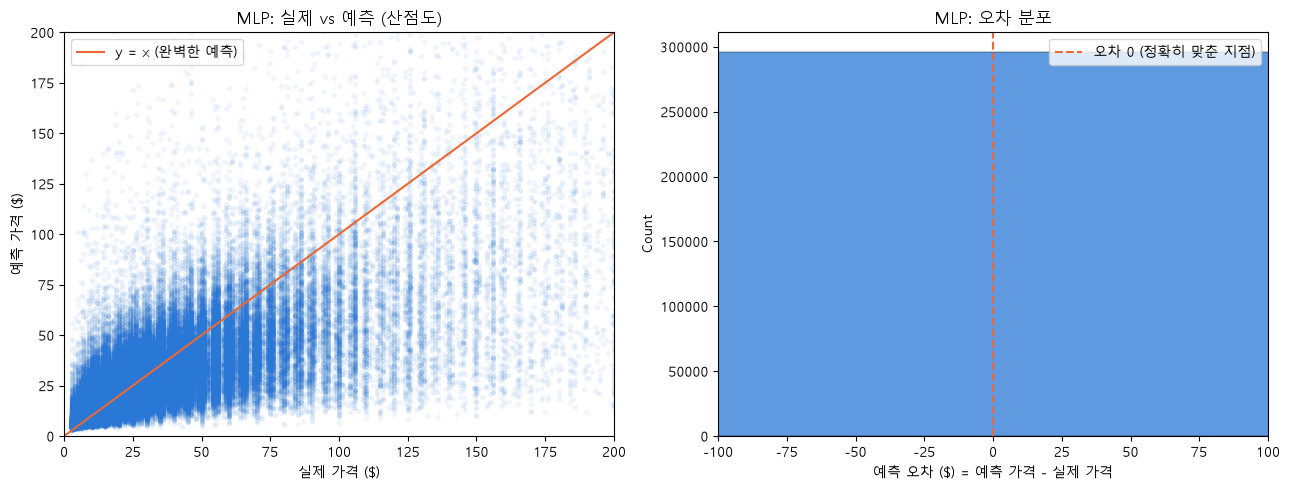


[셀 실행 시간: 5.97초]


In [46]:
# 실제 vs 예측 가격 - 전체 테스트셋을 그림으로 확인 (릿지 노트북과 동일한 형식)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(actual_price, predicted_price, alpha=0.05, s=8, color='#2a78d6')
max_val = 200  # 가격 대부분이 이 구간에 몰려 있어 보기 편하게 축 제한 (실제 최대값은 2000)
axes[0].plot([0, max_val], [0, max_val], color='#eb6834', linewidth=1.5, label='y = x (완벽한 예측)')
axes[0].set_xlim(0, max_val)
axes[0].set_ylim(0, max_val)
axes[0].set_xlabel('실제 가격 ($)')
axes[0].set_ylabel('예측 가격 ($)')
axes[0].set_title('MLP: 실제 vs 예측 (산점도)')
axes[0].legend()

sns.histplot(price_compare['차이(예측-실제)'], bins=100, ax=axes[1], color='#2a78d6')
axes[1].set_xlim(-100, 100)
axes[1].axvline(0, color='#eb6834', linestyle='--', label='오차 0 (정확히 맞춘 지점)')
axes[1].set_xlabel('예측 오차 ($) = 예측 가격 - 실제 가격')
axes[1].set_title('MLP: 오차 분포')
axes[1].legend()

plt.tight_layout()
plt.show()

In [47]:
# 릿지 vs MLP 최종 비교
comparison = pd.DataFrame({
    '모델': ['Ridge (선형, alpha=3.1623)', f'MLP (임베딩+비선형, val기준 최적 epoch {best_epoch:.0f})'],
    'RMSLE': [0.45223, test_rmsle],
})



[셀 실행 시간: 0.00초]


In [48]:
# 결과 확인
comparison


,모델,RMSLE
0,"Ridge (선형, alpha=3.1623)",0.452230
1,"MLP (임베딩+비선형, val기준 최적 epoch 15)",0.451373



[셀 실행 시간: 0.01초]


차이: -0.00086  (MLP가 더 좋음)


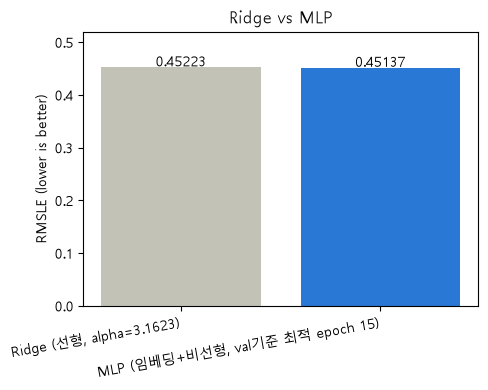


[셀 실행 시간: 0.14초]


In [49]:
diff = comparison['RMSLE'][1] - comparison['RMSLE'][0]
better = 'MLP' if diff < 0 else 'Ridge'
print(f'차이: {diff:+.5f}  ({better}가 더 좋음)')

plt.figure(figsize=(5, 4))
bars = plt.bar(comparison['모델'], comparison['RMSLE'], color=['#c3c2b7', '#2a78d6'])
plt.ylabel('RMSLE (lower is better)')
plt.title('Ridge vs MLP')
plt.xticks(rotation=10, ha='right')
for b in bars:
    plt.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.002, f'{b.get_height():.5f}', ha='center')
plt.ylim(0, max(comparison['RMSLE']) * 1.15)
plt.tight_layout()
plt.show()
